In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

sns.set(style="whitegrid")

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Jumlah data:", df.shape[0])
print("Jumlah variabel:", df.shape[1])
print("\nTipe data tiap variabel:")
print(df.dtypes)

print("\nJumlah masing-masing spesies:")
print(df['species'].value_counts())

Jumlah data: 150
Jumlah variabel: 5

Tipe data tiap variabel:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Jumlah masing-masing spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.median(numeric_only=True)

,0
sepal length (cm),5.80
sepal width (cm),3.00
petal length (cm),4.35
petal width (cm),1.30


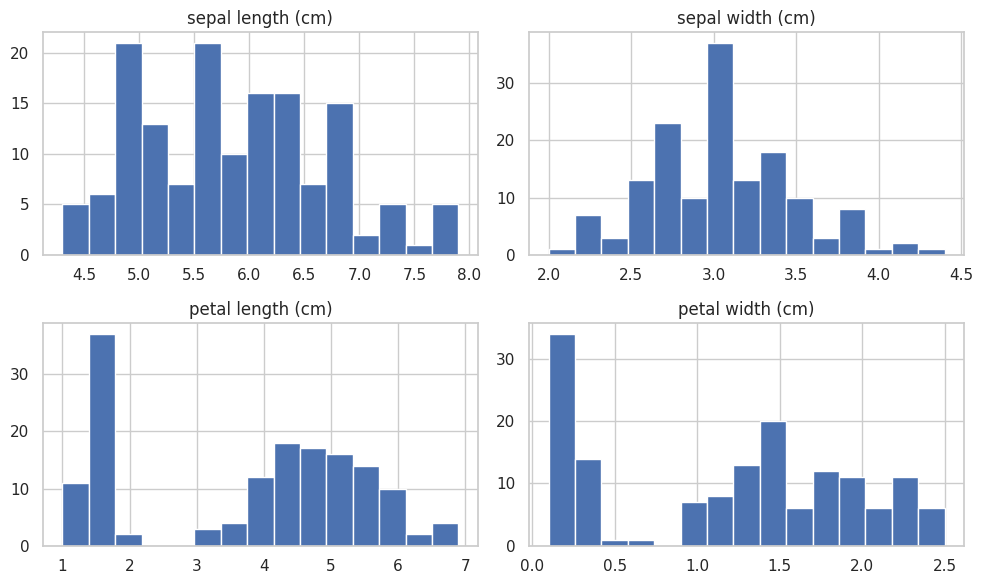

In [7]:
df.iloc[:, :-1].hist(figsize=(10,6), bins=15)
plt.tight_layout()
plt.show()

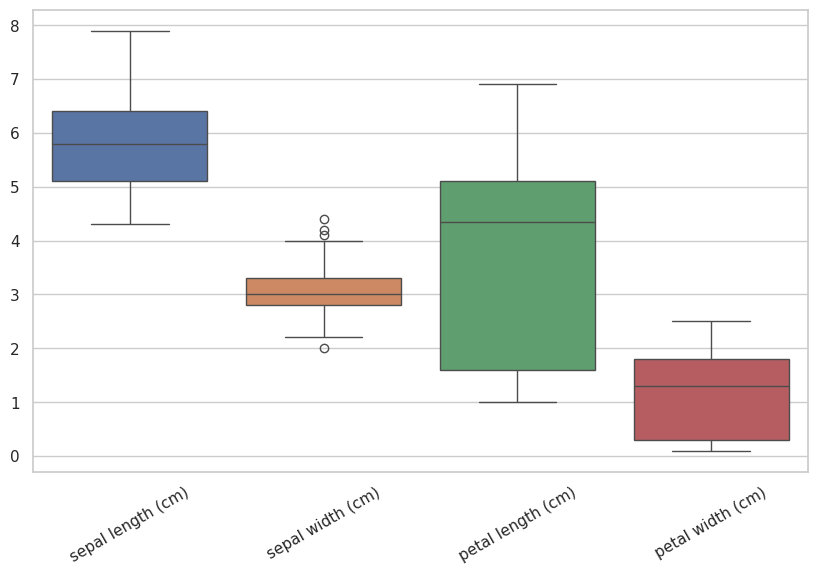

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:, :-1])
plt.xticks(rotation=30)
plt.show()

Penjelasan
Sepal length dan sepal width memiliki distribusi relatif simetris dengan sebaran data sedang dan minim outlier. Sebaliknya, petal length dan petal width menunjukkan distribusi tidak simetris (bimodal), menandakan pemisahan data yang jelas antar spesies, tanpa adanya outlier ekstrem.

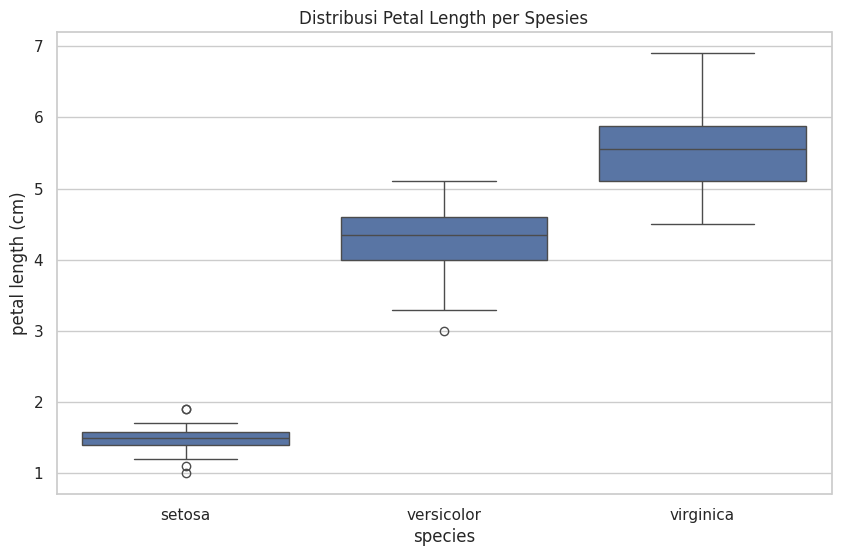

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title("Distribusi Petal Length per Spesies")
plt.show()

Panjang petal menunjukkan pemisahan yang sangat jelas antar spesies. Iris setosa memiliki petal paling pendek, iris versicolor berada pada rentang menengah, dan iris virginica memiliki petal paling panjang. Dengan perbedaan median dan sebaran yang tegas, variabel petal length sangat efektif digunakan sebagai fitur pembeda spesies Iris.

In [10]:
data = df['petal length (cm)']
n = len(data)

In [11]:
bootstrap_sample = np.random.choice(data, size=n, replace=True)

print("Mean asli:", data.mean())
print("Median asli:", data.median())
print("Mean bootstrap:", bootstrap_sample.mean())
print("Median bootstrap:", np.median(bootstrap_sample))

Mean asli: 3.7580000000000005
Median asli: 4.35
Mean bootstrap: 3.8879999999999995
Median bootstrap: 4.4


In [16]:
def bootstrap_means(data, B):
    means = []
    n = len(data)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    return np.array(means)

boot_100 = bootstrap_means(data, 100)
boot_1000 = bootstrap_means(data, 1000)
boot_10000 = bootstrap_means(data, 10000)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


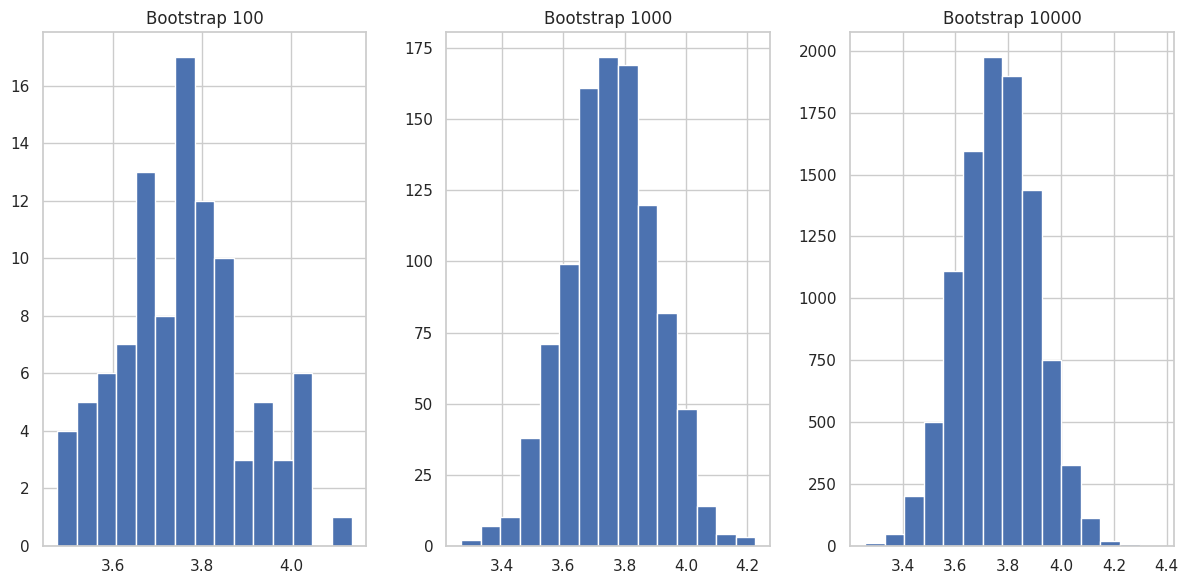

In [13]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.hist(boot_100, bins=15)
plt.title("Bootstrap 100")

plt.subplot(1,3,2)
plt.hist(boot_1000, bins=15)
plt.title("Bootstrap 1000")

plt.subplot(1,3,3)
plt.hist(boot_10000, bins=15)
plt.title("Bootstrap 10000")

plt.tight_layout()
plt.show()

/tmp/ipython-input-310/768374070.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([boot_100, boot_1000, boot_10000], labels=['100','1000','10000'])


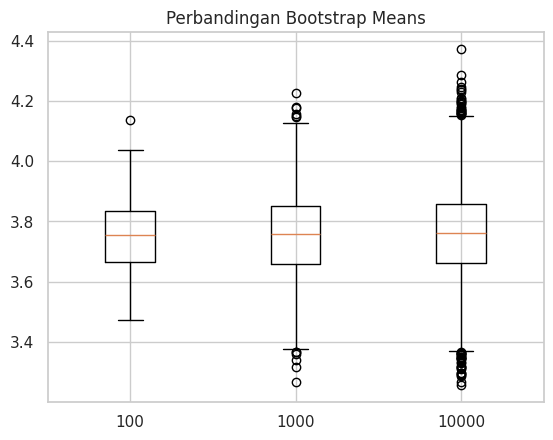

In [14]:
plt.boxplot([boot_100, boot_1000, boot_10000], labels=['100','1000','10000'])
plt.title("Perbandingan Bootstrap Means")
plt.show()

In [15]:
def ci_bootstrap(data):
    return np.percentile(data, [2.5, 97.5])

print("CI 100   :", ci_bootstrap(boot_100))
print("CI 1000  :", ci_bootstrap(boot_1000))
print("CI 10000 :", ci_bootstrap(boot_10000))

CI 100   : [3.50565 4.02115]
CI 1000  : [3.47063333 4.02803333]
CI 10000 : [3.47731667 4.04001667]


BAGIAN C
1. Mean bootstrap merupakan estimator yang tidak bias terhadap mean data asli.
2. Semakin besar jumlah bootstrap, semakin stabil dan representatif distribusi mean bootstrap.
3. Bootstrap 10000 menghasilkan estimasi mean dan interval kepercayaan yang paling stabil karena variabilitas statistiknya paling kecil.
4. Ya, mean data asli berada dalam interval kepercayaan (CI 95%) bootstrap. Metode bootstrap valid digunakan untuk mengestimasi parameter populasi.
5. Karena bootstrap menggunakan metode Sampling dengan pengembalian (with replacement)

Bagian D - Kesimpulan
1.  Insight Utama dari EDA Dataset Iris:
Hasil eksplorasi data (EDA) menunjukkan bahwa variabel petal length dan petal width memiliki kemampuan paling baik dalam membedakan spesies bunga Iris dibandingkan dengan variabel sepal length dan sepal width. Hal ini terlihat dari pola distribusi dan visualisasi boxplot yang memperlihatkan pemisahan data yang jelas antar spesies pada variabel petal. Sementara itu, variabel sepal menunjukkan tumpang tindih distribusi yang cukup besar, sehingga kurang optimal sebagai pembeda utama. Dengan demikian, variabel petal merupakan fitur paling informatif dalam proses klasifikasi spesies Iris.
2. Karakteristik Tiap Spesies:
*   Iris Setosa
Memiliki ukuran petal paling kecil dengan sebaran data sempit, menunjukkan karakteristik yang sangat konsisten dan mudah dibedakan dari spesies lain.
*   Iris Versicolor
Memiliki ukuran petal menengah dengan sebaran data sedang, menunjukkan variasi ukuran yang cukup beragam dan berada di antara setosa dan virginica.
*   Iris Virginica
Memiliki ukuran petal paling besar dengan sebaran data paling lebar, menunjukkan tingkat variasi tertinggi di antara ketiga spesies.
3. Manfaat Bootstrap dalam Analisis Data:
Bootstrap memberikan manfaat utama dalam mengestimasi parameter statistik dan mengukur ketidakpastian data tanpa memerlukan asumsi distribusi tertentu. Metode ini memungkinkan peneliti untuk:
*   Mengestimasi mean dan interval kepercayaan secara lebih akurat
*   Mengukur stabilitas statistik
*   Memahami variasi data sampel
Dengan demikian, bootstrap sangat bermanfaat terutama ketika ukuran sampel terbatas atau distribusi data tidak diketahui.
4. Jumlah Bootstrap yang Menurut Saya Cukup:
Berdasarkan hasil analisis, jumlah 1000 bootstrap sudah cukup optimal karena mampu menghasilkan estimasi mean dan interval kepercayaan yang stabil dengan waktu komputasi yang efisien.




